# Analyse results from Pypsa-Earth

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [51]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

## Path settings

In [52]:
# Network file
results_path = "/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/postnetworks/base_s_39_lvopt__144h_2050.nc"
network_path = "/mnt/e/H2GMA/Github/Europe/pypsa-eur/resources/networks/base.nc"
# Country shape file
regions_onshore_path = "/mnt/e/H2GMA/Github/Europe/pypsa-eur/resources/country_shapes.geojson"
# Renewable profile file
solar_path = "/mnt/e/H2GMA/Github/Europe/pypsa-eur/resources/profile_39_solar.nc"
onwind_path = "/mnt/e/H2GMA/Github/Europe/pypsa-eur/resources/profile_39_onwind.nc" 

## Energy system analysis setup - power and energy generation

In [53]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network base_s_39_lvopt__144h_2050.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


FENES color setting

In [54]:
def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(r, g, b)

FENES_color = n.carriers.color
FENES_color["nuclear"] = rgb_to_hex(206,55,62) #adapted
FENES_color["OCGT"] = rgb_to_hex(228,147,44)
FENES_color["coal"] = rgb_to_hex(80,80,80)
FENES_color["CCGT"] = rgb_to_hex(218,137,34) #adapted
FENES_color["biomass"] = rgb_to_hex(29,152,56)
FENES_color["lignite"] = rgb_to_hex(185,100,40)
FENES_color["oil"] = rgb_to_hex(0,0,0)
FENES_color["geothermal"] = rgb_to_hex(176,25,32)
FENES_color["hydro"] = rgb_to_hex(27,90,166)
FENES_color["offwind-ac"] = rgb_to_hex(18,143,207)
FENES_color["offwind-dc"] = rgb_to_hex(8,133,197) #adapted
FENES_color["onwind"] = rgb_to_hex(28,153,218) #adapted
FENES_color["solar"] = rgb_to_hex(228,203,58)
FENES_color["PHS"] = "#08ad97"
FENES_color["ror"] = "#4adbc8"
FENES_color["H2"] = "#ea048a"
FENES_color["battery"] = rgb_to_hex(140,191,62)

n.carriers.color = FENES_color

# Set export
n.carriers.loc["export", "nice_name"] = "Export"
n.carriers.loc["export", "color"] = "#800080"

/tmp/ipykernel_3651/2081982108.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FENES_color["nuclear"] = rgb_to_hex(206,55,62) #adapted
/tmp/ipykernel_3651/2081982108.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FENES_color["OCGT"] = rgb_to_hex(228,147,44)
/tmp/ipykernel_3651/2081982108.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  FENES_color["coal"] = rgb_to_hex(80,80,80)


## Data import check

Country check

Text(0.5, 1.0, 'FR, LT, CZ, DE, EE, LV, NO, SE, FI, LU, BE, MK, AL, XK, ES, DK, RO, HU, SK, PL, IE, GB, GR, AT, IT, CH, NL, RS, HR, SI, BG, ME, BA, PT')

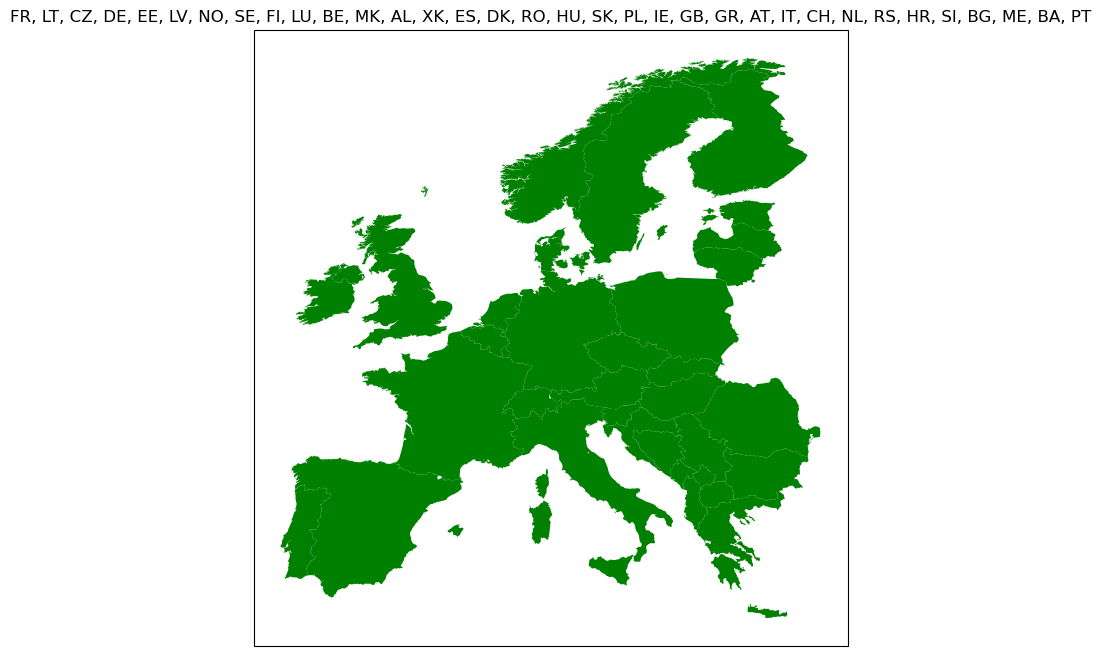

In [55]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [56]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 483 entries
Component 'Carrier' has 102 entries
Component 'GlobalConstraint' has 2 entries
Component 'Line' has 73 entries
Component 'LineType' has 36 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 1815 entries
Component 'Load' has 396 entries
Component 'Generator' has 402 entries
Component 'StorageUnit' has 56 entries
Component 'Store' has 282 entries


Snapshot check

In [57]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-07', '2013-01-13', '2013-01-19',
               '2013-01-25', '2013-01-31', '2013-02-06', '2013-02-12',
               '2013-02-18', '2013-02-24', '2013-03-02', '2013-03-08',
               '2013-03-14', '2013-03-20', '2013-03-26', '2013-04-01',
               '2013-04-07', '2013-04-13', '2013-04-19', '2013-04-25',
               '2013-05-01', '2013-05-07', '2013-05-13', '2013-05-19',
               '2013-05-25', '2013-05-31', '2013-06-06', '2013-06-12',
               '2013-06-18', '2013-06-24', '2013-06-30', '2013-07-06',
               '2013-07-12', '2013-07-18', '2013-07-24', '2013-07-30',
               '2013-08-05', '2013-08-11', '2013-08-17', '2013-08-23',
               '2013-08-29', '2013-09-04', '2013-09-10', '2013-09-16',
               '2013-09-22', '2013-09-28', '2013-10-04', '2013-10-10',
               '2013-10-16', '2013-10-22', '2013-10-28', '2013-11-03',
               '2013-11-09', '2013-11-15', '2013-11-21', '2013-11-27',
      

## Analyse energy system

Analyse the current capacity of the energy system - map view

In [58]:
default_color = '#000000'
# Set a default color for empty entries
n.carriers.color = n.carriers.color.replace('', default_color)


/home/alex-charly/anaconda3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_3651/3354516466.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


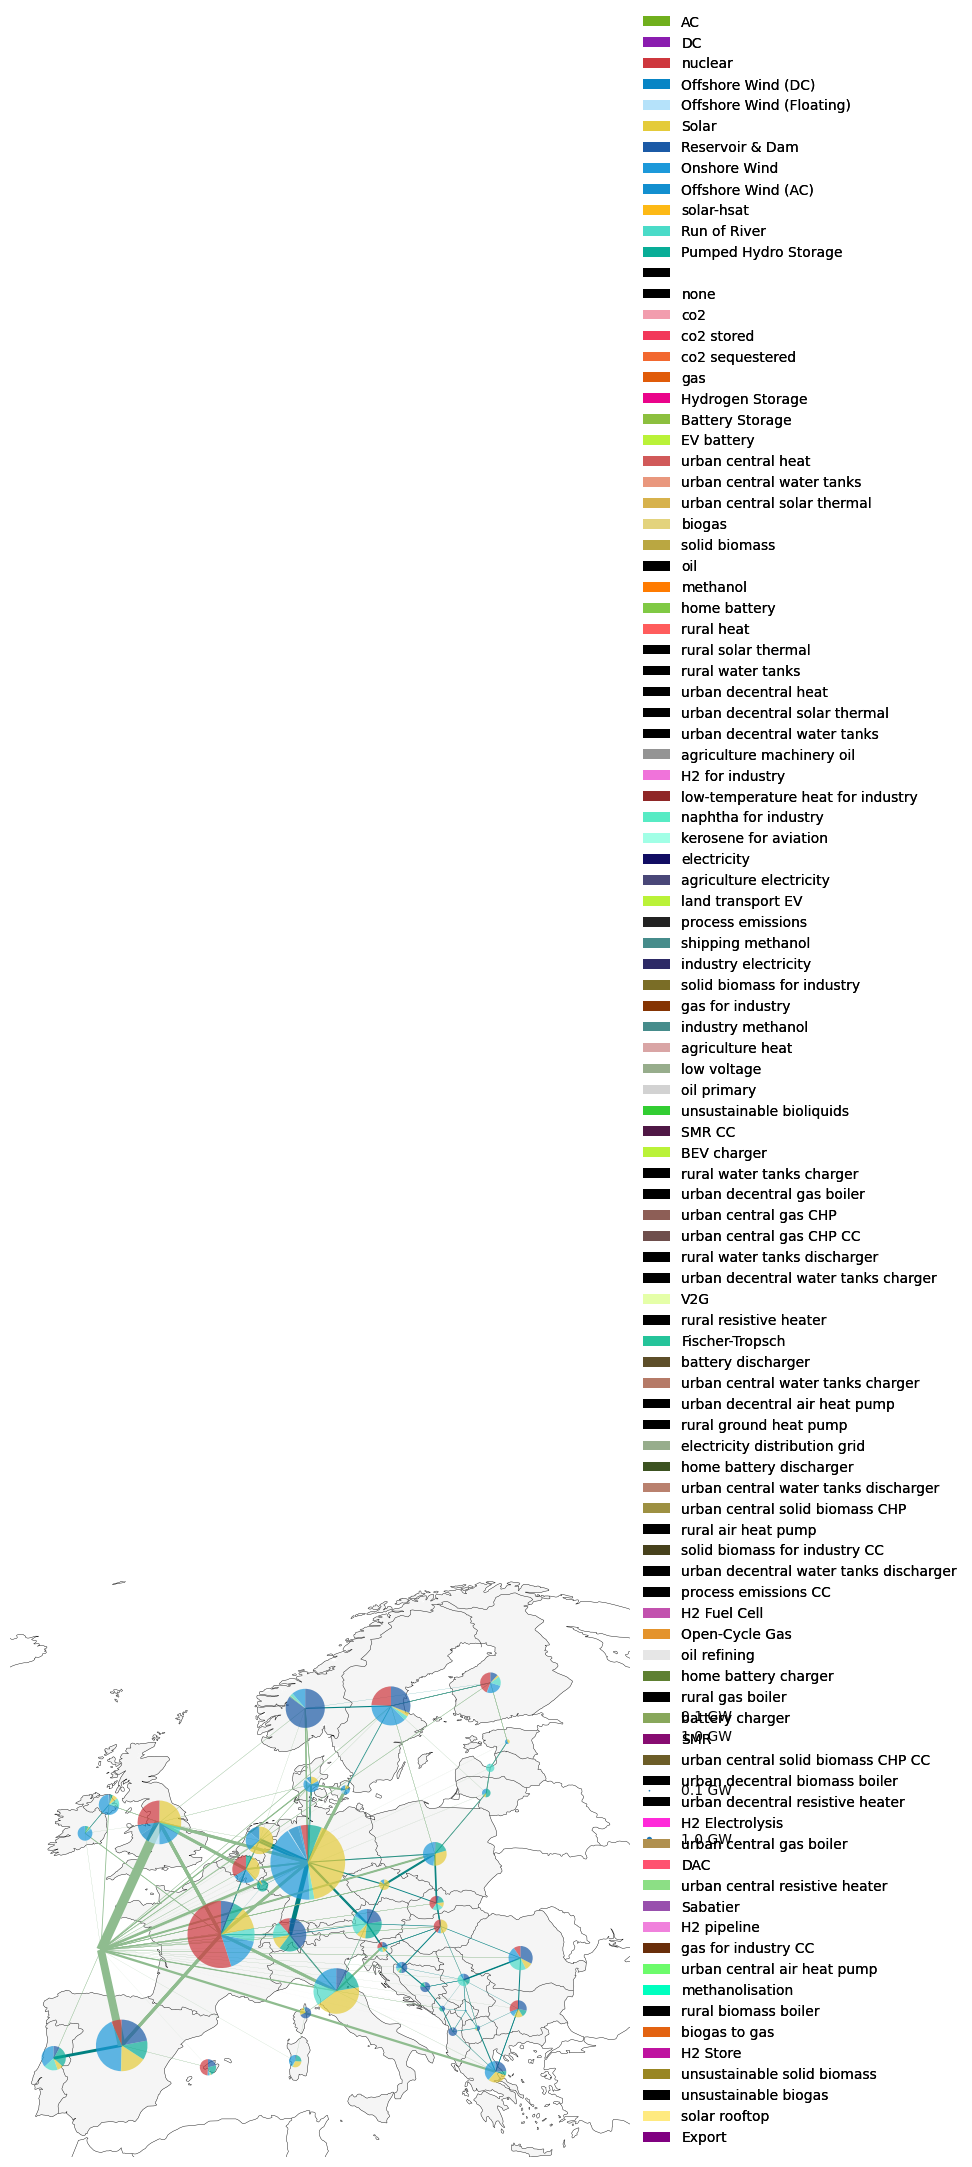

In [59]:
# Scale settings
bus_scale = 2e4
line_scale = 1e4

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

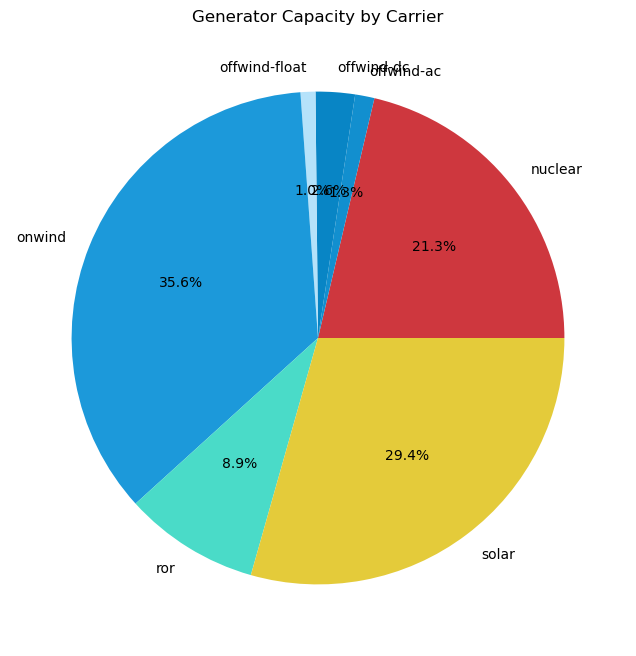

In [60]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
# Filter out carriers with zero capacity
filtered_capacity = generator_capacity_by_carrier[generator_capacity_by_carrier > 0]
# Get the corresponding colors
filtered_colors = n.carriers[n.carriers.index.isin(filtered_capacity.index)].color.reindex(filtered_capacity.index)
# Plot the pie chart
plt.pie(filtered_capacity, labels=filtered_capacity.index, autopct='%1.1f%%', colors=filtered_colors)
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [61]:
generator_capacity_by_carrier/1e3 # in GW

carrier
gas                                0.000000
nuclear                          110.658100
offwind-ac                         6.561647
offwind-dc                        13.371619
offwind-float                      5.072113
oil primary                        0.000000
onwind                           184.721712
ror                               46.063308
rural solar thermal                0.000000
solar                            152.551138
solar rooftop                      0.000000
solar-hsat                         0.000000
urban central solar thermal        0.000000
urban decentral solar thermal      0.000000
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/alex-charly/anaconda3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_3651/958174134.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


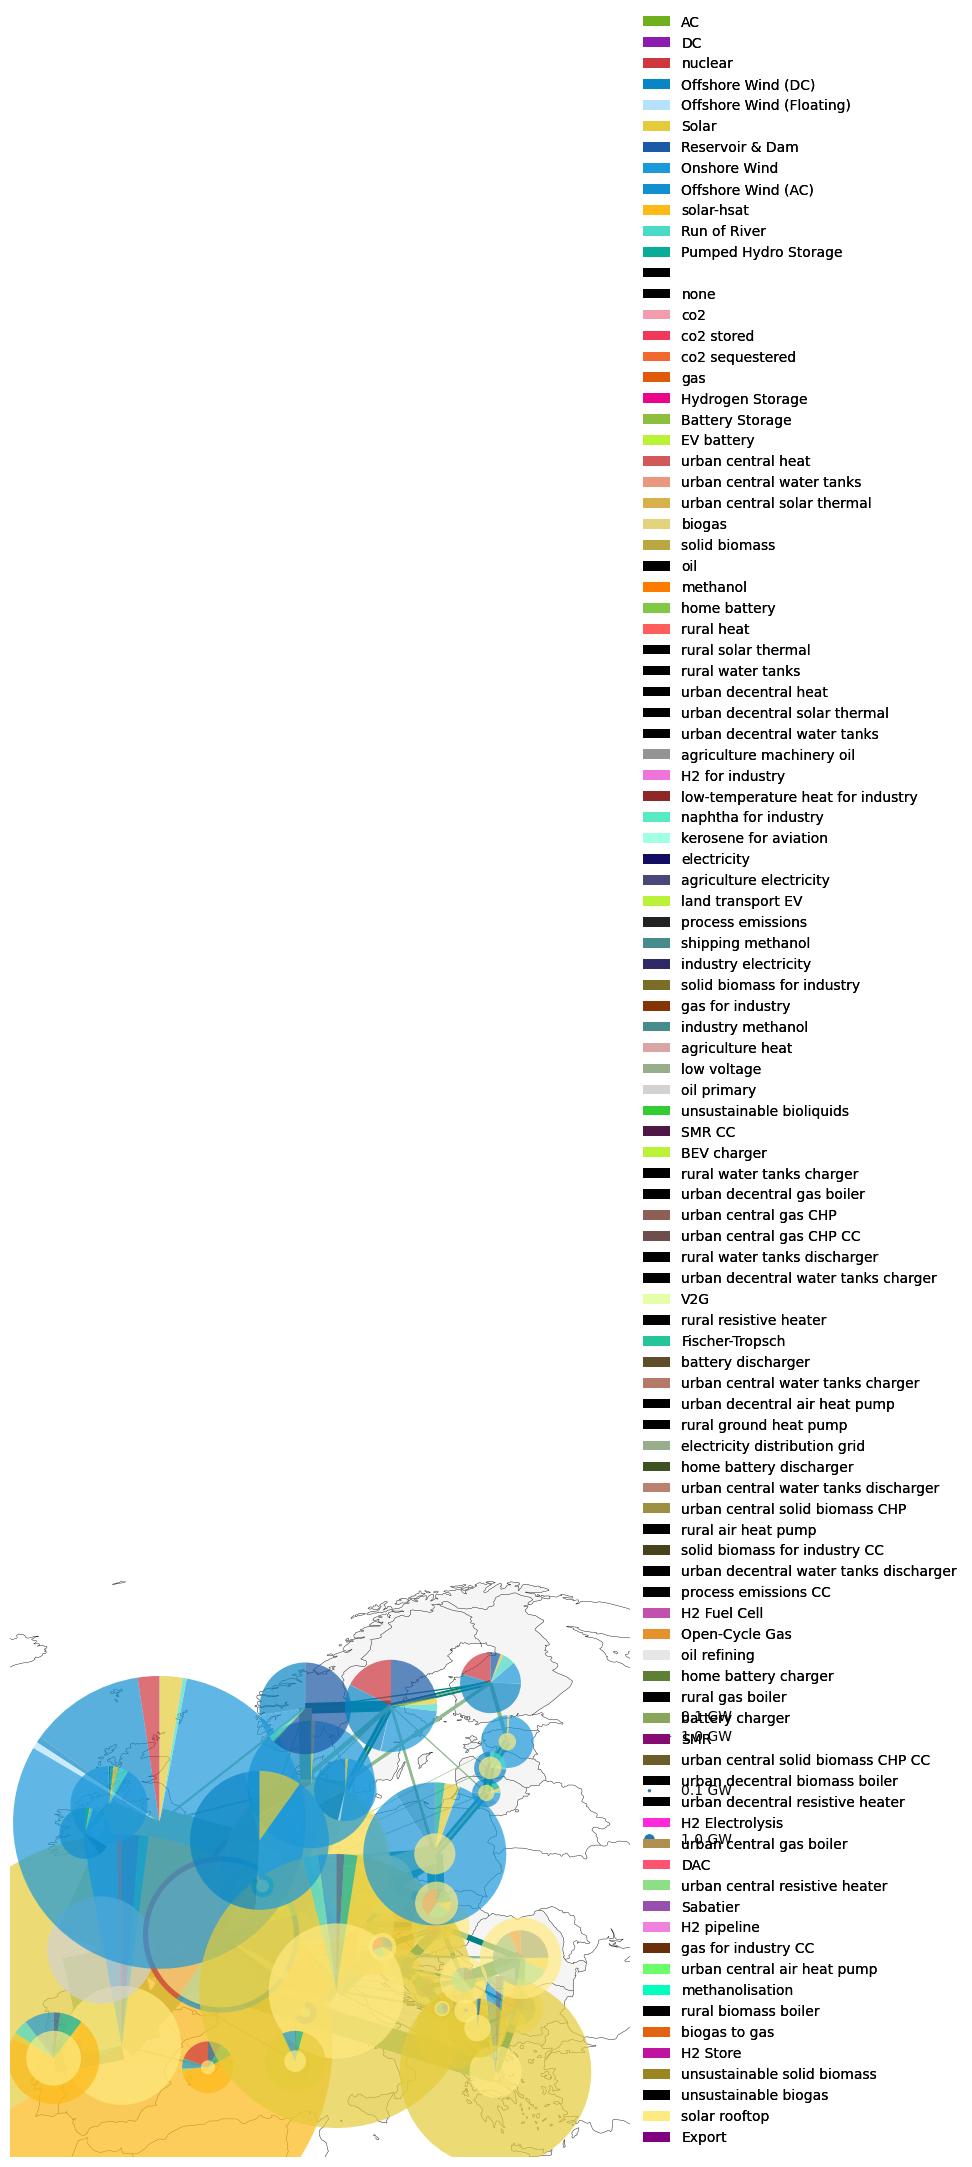

In [62]:
bus_scale = 5e3 
line_scale = 1e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Calculate emissions of future energy system

In [63]:
co2_emissions = pd.DataFrame(data=n.carriers[["co2_emissions", "nice_name"]]).set_index("nice_name").squeeze().rename_axis("carrier")

energy_production = n.statistics.energy_balance().Generator.droplevel(1).drop(["load", "export"], errors="ignore")

co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index]
co2_emissions_technology

carrier
Offshore Wind (AC)               0.0
Offshore Wind (DC)               0.0
Offshore Wind (Floating)         0.0
Onshore Wind                     0.0
Run of River                     0.0
Solar                            0.0
gas                              0.0
nuclear                          0.0
oil primary                      0.0
rural solar thermal              0.0
solar rooftop                    0.0
solar-hsat                       0.0
urban central solar thermal      0.0
urban decentral solar thermal    0.0
dtype: float64

In [64]:
co2_emissions_sum = co2_emissions_technology.sum()
co2_emissions_sum

0.0

In [65]:
n.global_constraints

,type,investment_period,carrier_attribute,sense,constant,mu
GlobalConstraint,,,,,,
CO2Limit,co2_atmosphere,NaN,co2_emissions,<=,0.0,-460.905059
co2_sequestration_limit,operational_limit,NaN,co2 sequestered,>=,-200000000.0,297.965141


Analys the future generation capacity expansion of the energy system - bar chart

<Axes: title={'center': 'Generator capacity expansion in GW'}, xlabel='carrier'>

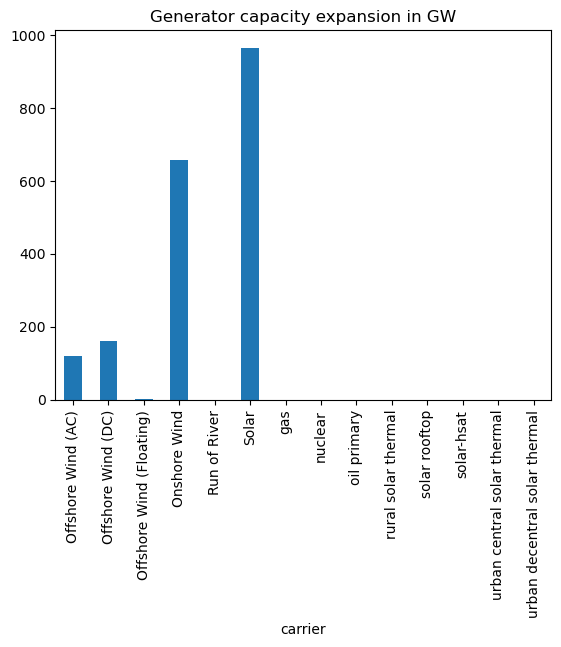

In [66]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [67]:
generation_capacity_expansion # In GW

carrier
Offshore Wind (AC)               119.429852
Offshore Wind (DC)               160.707329
Offshore Wind (Floating)           2.763736
Onshore Wind                     655.747051
Run of River                       0.000000
Solar                            964.793958
gas                                     NaN
nuclear                            0.000000
oil primary                             NaN
rural solar thermal                     NaN
solar rooftop                           NaN
solar-hsat                              NaN
urban central solar thermal             NaN
urban decentral solar thermal           NaN
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

In [68]:
# Color for figure
n.carriers.loc["H2 electrolysis", "nice_name"] = "H2 Electrolysis"
n.carriers.loc["H2 electrolysis", "color"] = "#ea048a"
n.carriers.loc["H2 fuel cell", "nice_name"] = "H2 Fuel Cell"
n.carriers.loc["H2 fuel cell", "color"] = "#ea048a"
n.carriers.loc["battery charger", "nice_name"] = "Battery Charger"
n.carriers.loc["battery charger", "color"] = rgb_to_hex(140,191,62)
n.carriers.loc["battery discharger", "nice_name"] = "Battery Discharger"
n.carriers.loc["battery discharger", "color"] = rgb_to_hex(140,191,62)
n.carriers.loc["load", "nice_name"] = "Load"
n.carriers.loc["load", "color"] = "#8b0000"

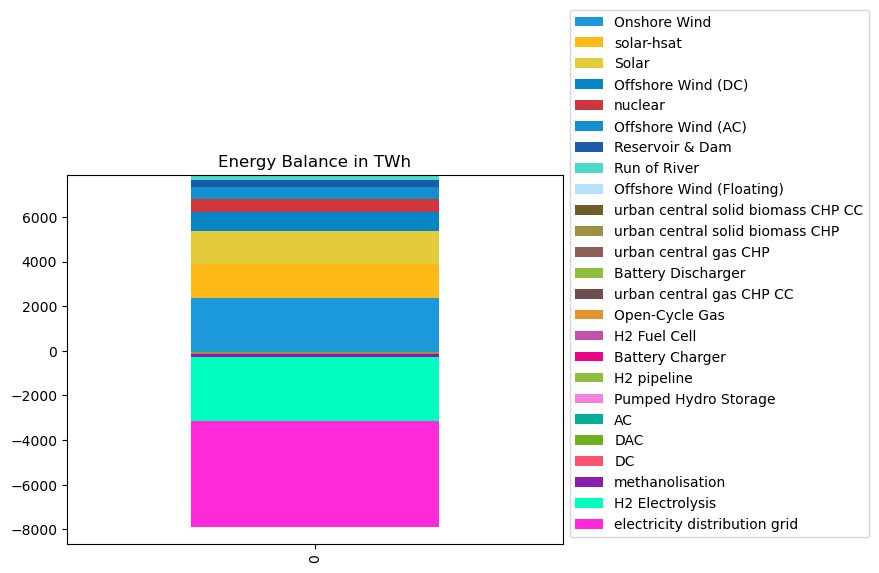

In [69]:
# Set the index of n.carriers to nice_name
color_setting = n.carriers.set_index('nice_name')

# Calculate energy balance
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().sort_values(ascending=False).div(1e6).to_frame().T
#energy_balance.drop(columns=["Load"], inplace=True)
energy_balance.rename(columns={'-': 'Load'}, inplace=True)

# Get the colors for the carriers
colors = color_setting.loc[energy_balance.columns, 'color']

# Plot the bar chart with colors
fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=colors)

# Adjust legend
ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()


Analyse the future energy generation of the energy system - tabular view

In [70]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier                                 bus_carrier                
StorageUnit  Pumped Hydro Storage                    AC                            -9.010880e+00
             Reservoir & Dam                         AC                             3.408406e+02
Generator    Offshore Wind (AC)                      AC                             5.197575e+02
             Offshore Wind (DC)                      AC                             8.635068e+02
             Offshore Wind (Floating)                AC                             3.290419e+01
             Onshore Wind                            AC                             2.370031e+03
             Run of River                            AC                             1.671004e+02
             Solar                                   AC                             1.475459e+03
             gas                                     gas                            2.101165e-05
             nuclear                          

In [94]:
n.statistics.energy_balance().Load

carrier                            bus_carrier               
H2 for industry                    Hydrogen Storage             -1.775100e+08
agriculture electricity            low voltage                  -3.752588e+07
agriculture heat                   rural heat                   -2.148117e+08
agriculture machinery oil          agriculture machinery oil    -1.028476e+08
electricity                        low voltage                  -1.574966e+09
gas for industry                   gas for industry             -2.313600e+08
industry electricity               low voltage                  -1.769310e+09
industry methanol                  industry methanol            -8.740000e+06
kerosene for aviation              kerosene for aviation        -7.439070e+08
land transport EV                  EV battery                   -9.805412e+08
low-temperature heat for industry  urban central heat           -5.929000e+07
                                   urban decentral heat         -2.000000e+05
na

## Analyse pv and wind potential - map view

In [84]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"/mnt/e/H2GMA/Github/Europe/pypsa-eur/resources/regions_{voronoi}_base_s_39.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

INFO:pypsa.io:Imported network base.nc has buses, carriers, lines, links, shapes, transformers


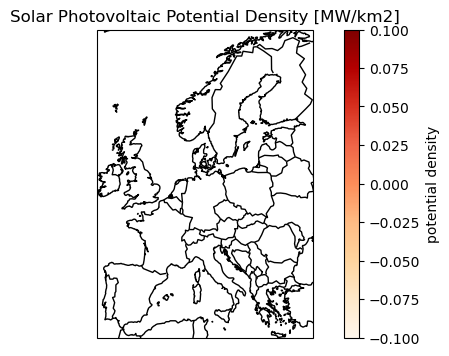

In [85]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

INFO:pypsa.io:Imported network base.nc has buses, carriers, lines, links, shapes, transformers


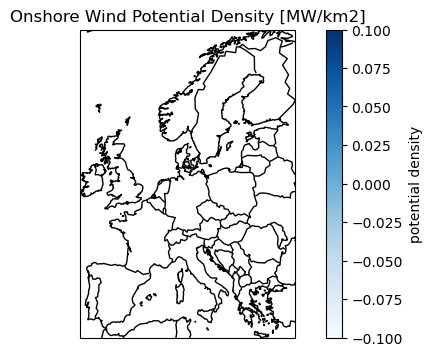

In [86]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Levelized cost of electricity

In [78]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity generation
# n.statistics.market_value() ?
lcoe = n.objective/n.statistics.energy_balance().Generator.sum()
lcoe 

71.41587179141509

In [79]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity demand
lcoe = n.objective/n.statistics.energy_balance().Load.sum()*(-1)
lcoe 

61.676927424826594

Average THG value

In [80]:
THG_Strom = co2_emissions_technology.sum()/n.statistics.energy_balance().Generator.sum()
THG_Strom #t CO2/MWh Strom bzw. kg CO2/kWh Strom
THG_H2 = THG_Strom/0.65 #Wirkungsgrad Elektrolyseur
THG_H2 #kg CO2/kWh H2
THG_H2 = THG_H2*33.33 #kWh/kg
THG_H2 # kg CO2/kg H2

0.0